# Анализ результатов: SSL Multi-Task EMO + AH

Сравниваем два набора экспериментов:
- **`best_models/`** — с взвешенным EMO-лоссом (`flag_emo_weight=True`), E3–E8
- **`best_models_wo_class_weigths_er/`** — без взвешивания EMO, только E3–E5

Разделы:
1. Загрузка данных  
2. Итоговая ablation-таблица (test-метрики, mean ± std)  
3. Сравнение WITH vs WITHOUT class weights (E3 / E4 / E5)  
4. Кривые обучения: val overall F1  
5. Кривые потерь: supervised vs SSL  
6. SSL-динамика: покрытие псевдо-меток по эпохам  
7. Распределение EMO псевдо-меток по классам  
8. Стабильность между сидами  
9. Выводы

In [2]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110

DIR_W  = Path("../../best_models")                       # с class weights EMO
DIR_WO = Path("../../best_models_wo_class_weigths_er")   # без class weights EMO

SEEDS = [42, 0, 123]
METRICS = ["emo_mf1", "emo_uar", "ah_mf1", "ah_uar", "overall_f1"]
METRIC_LABELS = {
    "emo_mf1":    "EMO mF1",
    "emo_uar":    "EMO UAR",
    "ah_mf1":     "AH mF1",
    "ah_uar":     "AH UAR",
    "overall_f1": "Overall F1",
}

# Описания экспериментов
EXP_META = {
    "E3_fusion_no_ssl":    {"label": "E3 No-SSL",           "color": "#9e9e9e", "ls": "-"},
    "E4_fusion_ssl":       {"label": "E4 SSL thr=0.6",      "color": "#5b9bd5", "ls": "-"},
    "E5_fusion_ssl_thr08": {"label": "E5 SSL thr=0.8",      "color": "#f4a042", "ls": "-"},
    "E6_fusion_ssl_lam01": {"label": "E6 SSL λ=0.1",        "color": "#6abf69", "ls": "--"},
    "E7_fusion_ssl_lam03": {"label": "E7 SSL λ=0.3",        "color": "#e05252", "ls": "--"},
    "E8_fusion_gradnorm":  {"label": "E8 GradNorm",         "color": "#a67cbf", "ls": "-."},
}

EMO_CLASSES = ["Neutral", "Anger", "Disgust", "Surprise", "Happiness", "Sadness", "Fear"]

# ─── Загрузка данных ─────────────────────────────────────────────────────────

def load_histories(directory):
    hists = {}
    for f in sorted(os.listdir(directory)):
        if f.endswith("_history.json") and f[0] == "E":
            exp_name = f.replace("_history.json", "")
            with open(directory / f) as fp:
                hists[exp_name] = json.load(fp)
    return hists

def load_ablation(directory):
    with open(directory / "ablation_results.json") as f:
        return json.load(f)

hists_w  = load_histories(DIR_W)
hists_wo = load_histories(DIR_WO)
ab_w     = load_ablation(DIR_W)
ab_wo    = load_ablation(DIR_WO)

print(f"best_models:                 {len(hists_w)} history files, {len(ab_w)} experiments")
print(f"best_models_wo_class_w...:   {len(hists_wo)} history files, {len(ab_wo)} experiments")
print()
print("Эксперименты (with weights):", sorted(ab_w.keys()))
print("Эксперименты (wo weights):  ", sorted(ab_wo.keys()))

best_models:                 18 history files, 6 experiments
best_models_wo_class_w...:   9 history files, 3 experiments

Эксперименты (with weights): ['E3_fusion_no_ssl', 'E4_fusion_ssl', 'E5_fusion_ssl_thr08', 'E6_fusion_ssl_lam01', 'E7_fusion_ssl_lam03', 'E8_fusion_gradnorm']
Эксперименты (wo weights):   ['E3_fusion_no_ssl', 'E4_fusion_ssl', 'E5_fusion_ssl_thr08']


## 2. Итоговая ablation-таблица (test-метрики)

In [5]:
def make_ablation_df(ab_dict):
    rows = []
    for exp, metrics in ab_dict.items():
        row = {"experiment": exp, "label": EXP_META.get(exp, {}).get("label", exp)}
        for m in METRICS:
            vals = np.array([v for v in metrics[m] if v is not None])
            row[f"{m}_mean"] = vals.mean()
            row[f"{m}_std"]  = vals.std()
            row[f"{m}_str"]  = f"{vals.mean():.4f} ±{vals.std():.3f}"
        rows.append(row)
    return pd.DataFrame(rows).set_index("experiment")

df_w  = make_ablation_df(ab_w)
df_wo = make_ablation_df(ab_wo)

# Красивая таблица для отображения
def show_table(df, title):
    display_cols = {m: METRIC_LABELS[m] for m in METRICS}
    out = df[["label"] + [f"{m}_str" for m in METRICS]].copy()
    out.columns = ["Experiment"] + list(display_cols.values())
    print(f"\n{'='*85}")
    print(f"  {title}")
    print(f"{'='*85}")
    print(out.to_string(index=False))

show_table(df_w,  "best_models  (с class weights EMO)  — E3–E8  — 3 seeds mean ± std")
show_table(df_wo, "best_models_wo  (без class weights EMO)  — E3–E5  — 3 seeds mean ± std")


  best_models  (с class weights EMO)  — E3–E8  — 3 seeds mean ± std
    Experiment       EMO mF1       EMO UAR        AH mF1        AH UAR    Overall F1
     E3 No-SSL 0.5801 ±0.003 0.6128 ±0.005 0.6627 ±0.005 0.6797 ±0.008 0.6214 ±0.003
E4 SSL thr=0.6 0.5706 ±0.004 0.6073 ±0.004 0.6558 ±0.005 0.6723 ±0.005 0.6132 ±0.001
E5 SSL thr=0.8 0.5750 ±0.004 0.6090 ±0.001 0.6600 ±0.005 0.6728 ±0.005 0.6175 ±0.004
  E6 SSL λ=0.1 0.5746 ±0.005 0.6093 ±0.003 0.6576 ±0.003 0.6707 ±0.003 0.6161 ±0.003
  E7 SSL λ=0.3 0.5719 ±0.004 0.6081 ±0.002 0.6592 ±0.008 0.6760 ±0.006 0.6155 ±0.003
   E8 GradNorm 0.5768 ±0.003 0.6102 ±0.005 0.6580 ±0.008 0.6729 ±0.007 0.6174 ±0.005

  best_models_wo  (без class weights EMO)  — E3–E5  — 3 seeds mean ± std
    Experiment       EMO mF1       EMO UAR        AH mF1        AH UAR    Overall F1
     E3 No-SSL 0.5810 ±0.003 0.5938 ±0.006 0.6507 ±0.012 0.6638 ±0.015 0.6158 ±0.008
E4 SSL thr=0.6 0.5829 ±0.002 0.5983 ±0.000 0.6605 ±0.004 0.6782 ±0.001 0.6217 ±0.003
E5 SSL 

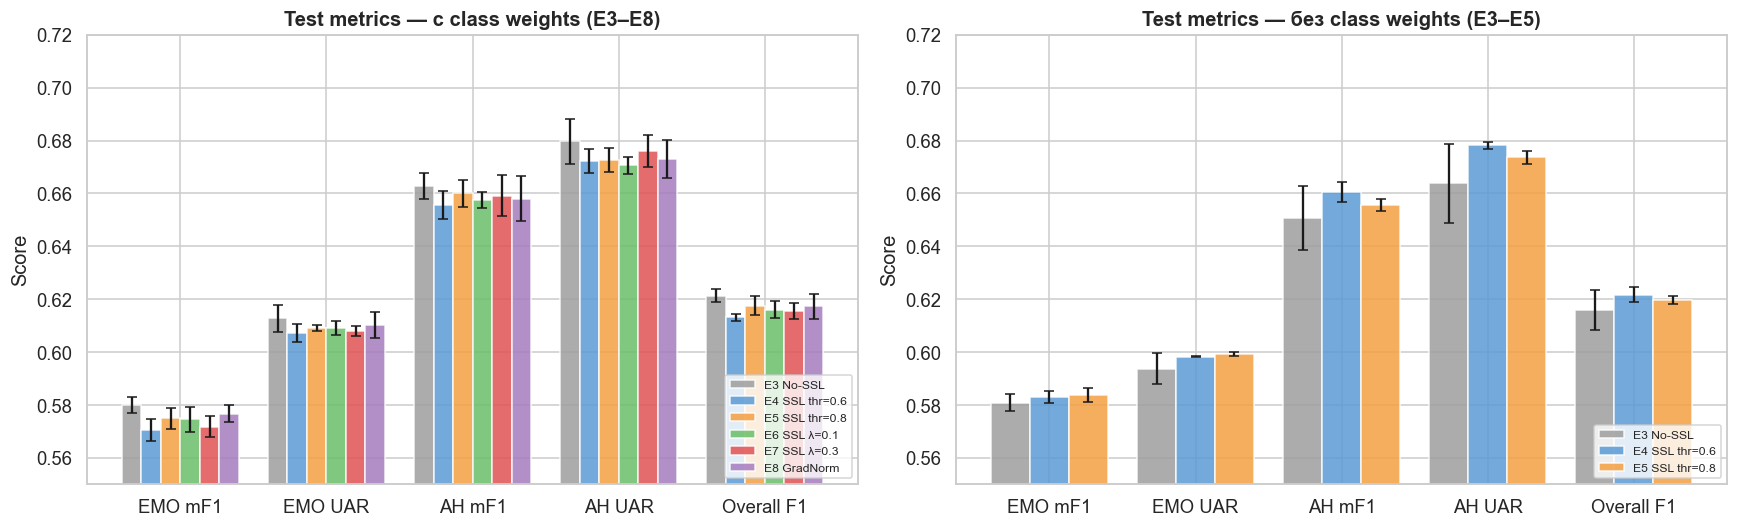

In [6]:
# Визуальная ablation: grouped bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

def plot_ablation_bars(ax, df, title):
    exps   = list(df.index)
    colors = [EXP_META.get(e, {}).get("color", "#aaa") for e in exps]
    x = np.arange(len(METRICS))
    width = 0.8 / len(exps)
    for i, (exp, color) in enumerate(zip(exps, colors)):
        means = [df.loc[exp, f"{m}_mean"] for m in METRICS]
        stds  = [df.loc[exp, f"{m}_std"]  for m in METRICS]
        label = EXP_META.get(exp, {}).get("label", exp)
        offset = (i - len(exps)/2 + 0.5) * width
        ax.bar(x + offset, means, width, yerr=stds, label=label,
               color=color, capsize=3, alpha=0.85, edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels([METRIC_LABELS[m] for m in METRICS])
    ax.set_ylabel("Score")
    ax.set_ylim(0.55, 0.72)
    ax.set_title(title, fontweight="bold")
    ax.legend(fontsize=8, loc="lower right")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

plot_ablation_bars(axes[0], df_w,  "Test metrics — с class weights (E3–E8)")
plot_ablation_bars(axes[1], df_wo, "Test metrics — без class weights (E3–E5)")
plt.tight_layout()
plt.show()

## 3. Сравнение WITH vs WITHOUT class weights (E3 / E4 / E5)

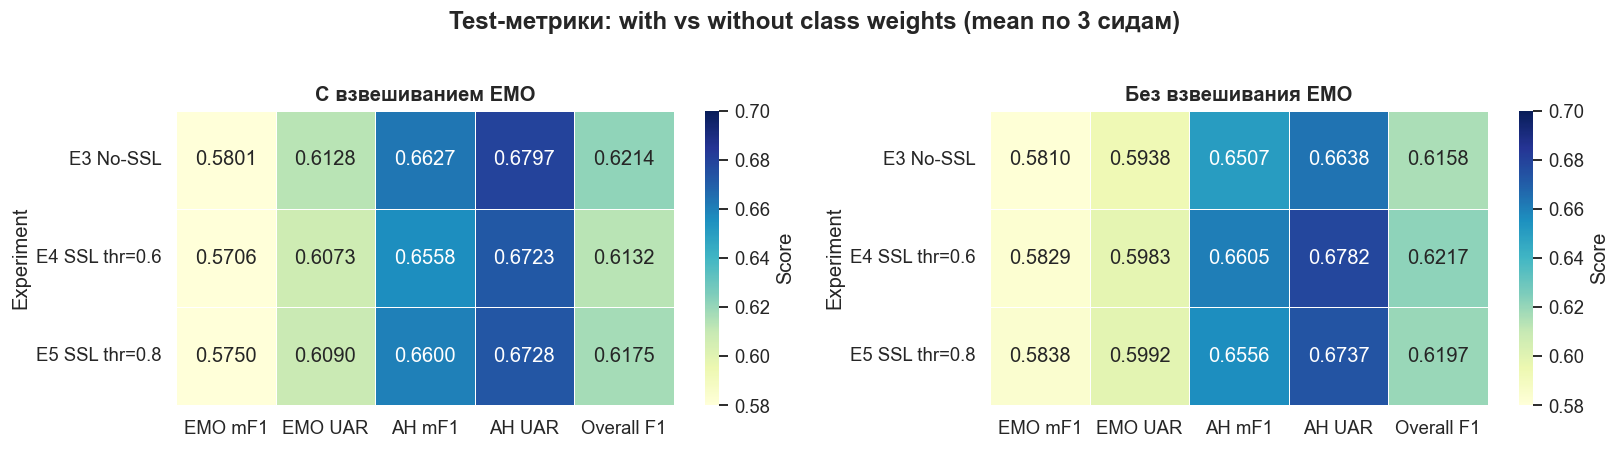

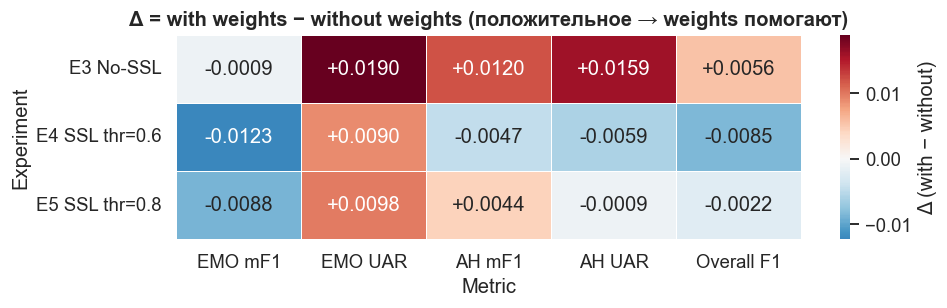

In [7]:
common_exps = ["E3_fusion_no_ssl", "E4_fusion_ssl", "E5_fusion_ssl_thr08"]

rows = []
for exp in common_exps:
    label = EXP_META[exp]["label"]
    for m in METRICS:
        w_mean  = df_w.loc[exp,  f"{m}_mean"]
        wo_mean = df_wo.loc[exp, f"{m}_mean"]
        rows.append({
            "Experiment": label,
            "Metric":     METRIC_LABELS[m],
            "With weights": w_mean,
            "Without weights": wo_mean,
            "Δ (with − wo)": w_mean - wo_mean,
        })

cmp_df = pd.DataFrame(rows)

# Heatmap of delta
delta_pivot = cmp_df.pivot(index="Experiment", columns="Metric", values="Δ (with − wo)")

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Absolute values side-by-side
for ax, col, title in [
    (axes[0], "With weights",    "С взвешиванием EMO"),
    (axes[1], "Without weights", "Без взвешивания EMO"),
]:
    piv = cmp_df.pivot(index="Experiment", columns="Metric", values=col)
    piv = piv[[METRIC_LABELS[m] for m in METRICS]]
    sns.heatmap(piv, annot=True, fmt=".4f", cmap="YlGnBu", ax=ax,
                vmin=0.58, vmax=0.70, linewidths=0.5, linecolor="white",
                cbar_kws={"label": "Score"})
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("")

plt.suptitle("Test-метрики: with vs without class weights (mean по 3 сидам)", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Delta heatmap
fig, ax = plt.subplots(figsize=(9, 3))
delta_pivot = delta_pivot[[METRIC_LABELS[m] for m in METRICS]]
sns.heatmap(delta_pivot, annot=True, fmt="+.4f", cmap="RdBu_r", center=0,
            ax=ax, linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Δ (with − without)"})
ax.set_title("Δ = with weights − without weights (положительное → weights помогают)", fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Кривые обучения: val overall F1 по эпохам

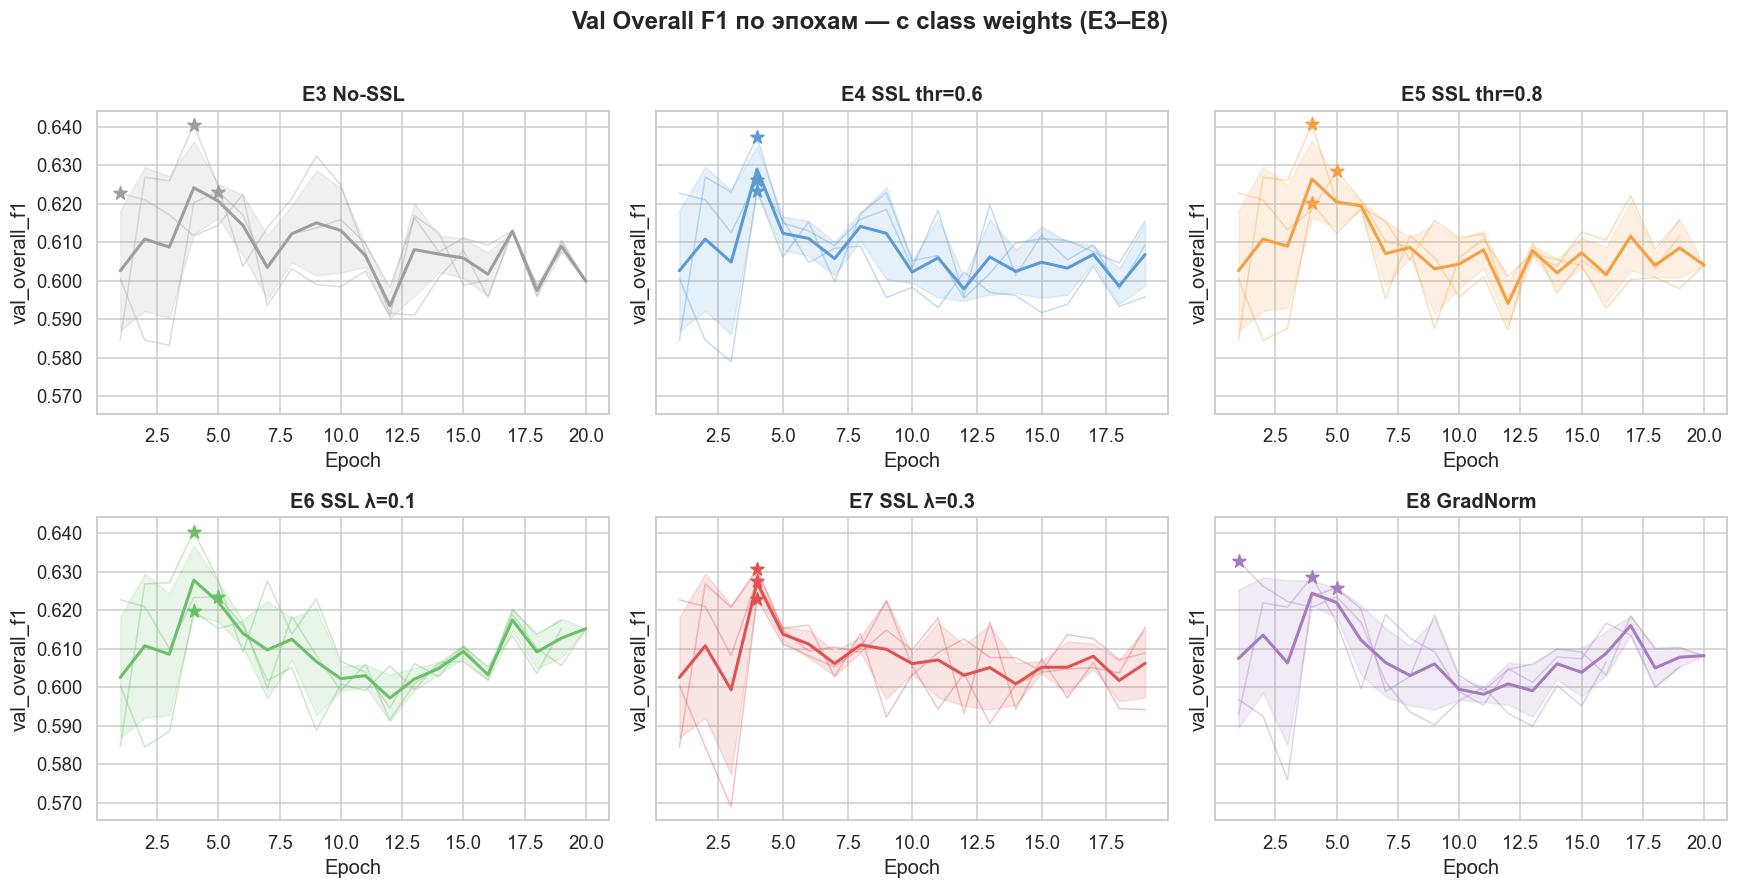

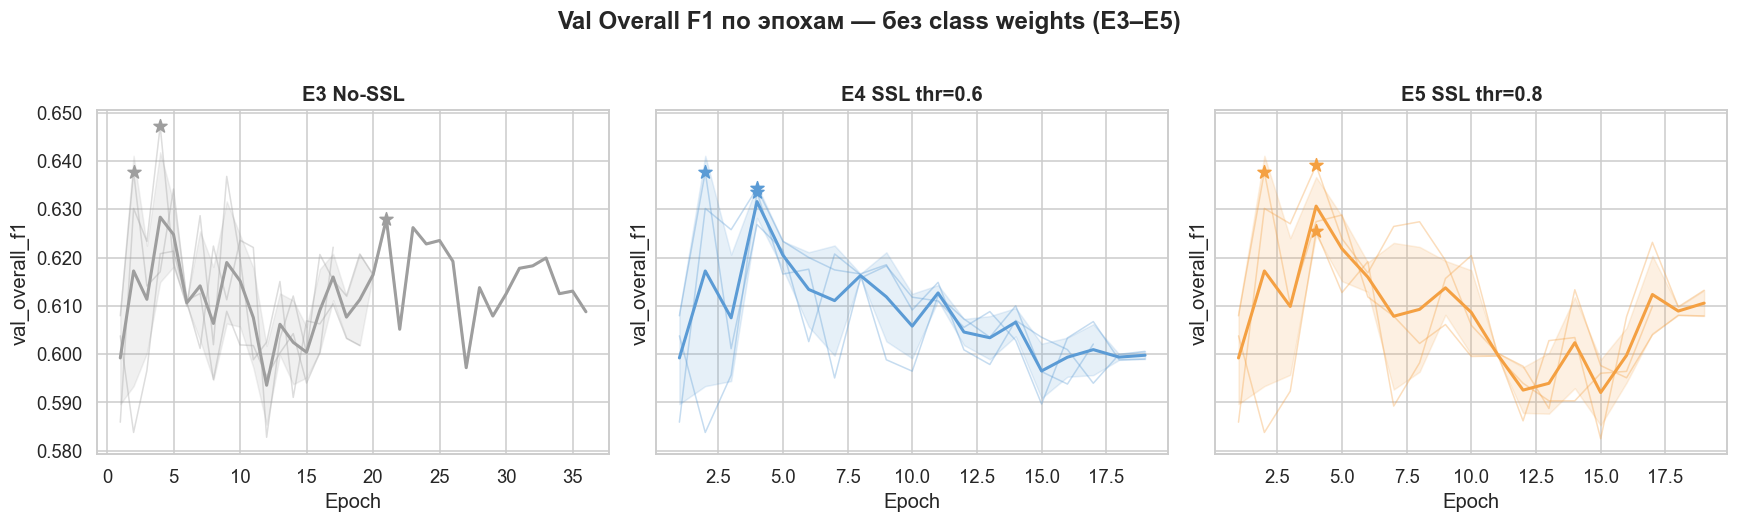

In [8]:
def get_exp_base(key):
    for base in EXP_META:
        if key.startswith(base):
            return base
    return None

def plot_learning_curves(hists, suptitle, metric="val_overall_f1"):
    # Группируем по базовому эксперименту
    groups = {}
    for key, h in hists.items():
        base = get_exp_base(key)
        if base:
            groups.setdefault(base, []).append(h[metric])

    fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=False, sharey=True)
    axes = axes.flatten()

    for i, (base, curves) in enumerate(sorted(groups.items())):
        if i >= len(axes):
            break
        ax = axes[i]
        meta = EXP_META.get(base, {"color": "#555", "label": base})
        max_len = max(len(c) for c in curves)
        arr = np.full((len(curves), max_len), np.nan)
        for j, c in enumerate(curves):
            arr[j, :len(c)] = c
        mean_curve = np.nanmean(arr, axis=0)
        std_curve  = np.nanstd(arr,  axis=0)
        epochs = np.arange(1, max_len + 1)

        for j, (c, s) in enumerate(zip(arr, SEEDS)):
            ax.plot(epochs[:len([x for x in c if not np.isnan(x)])],
                    c[~np.isnan(c)],
                    alpha=0.35, linewidth=1, color=meta["color"], label=f"seed {s}" if j == 0 else None)
        ax.plot(epochs, mean_curve, color=meta["color"], linewidth=2, label="mean")
        ax.fill_between(epochs, mean_curve - std_curve, mean_curve + std_curve,
                        alpha=0.15, color=meta["color"])

        # Best val point per seed
        for c in arr:
            valid = c[~np.isnan(c)]
            best_ep = np.nanargmax(c) + 1
            ax.scatter(best_ep, np.nanmax(c), marker="*", color=meta["color"],
                       s=80, zorder=5)

        ax.set_title(meta["label"], fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(METRIC_LABELS.get(metric, metric))
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))

    # Скрыть лишние оси
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(suptitle, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

plot_learning_curves(hists_w,  "Val Overall F1 по эпохам — с class weights (E3–E8)")
plot_learning_curves(hists_wo, "Val Overall F1 по эпохам — без class weights (E3–E5)")

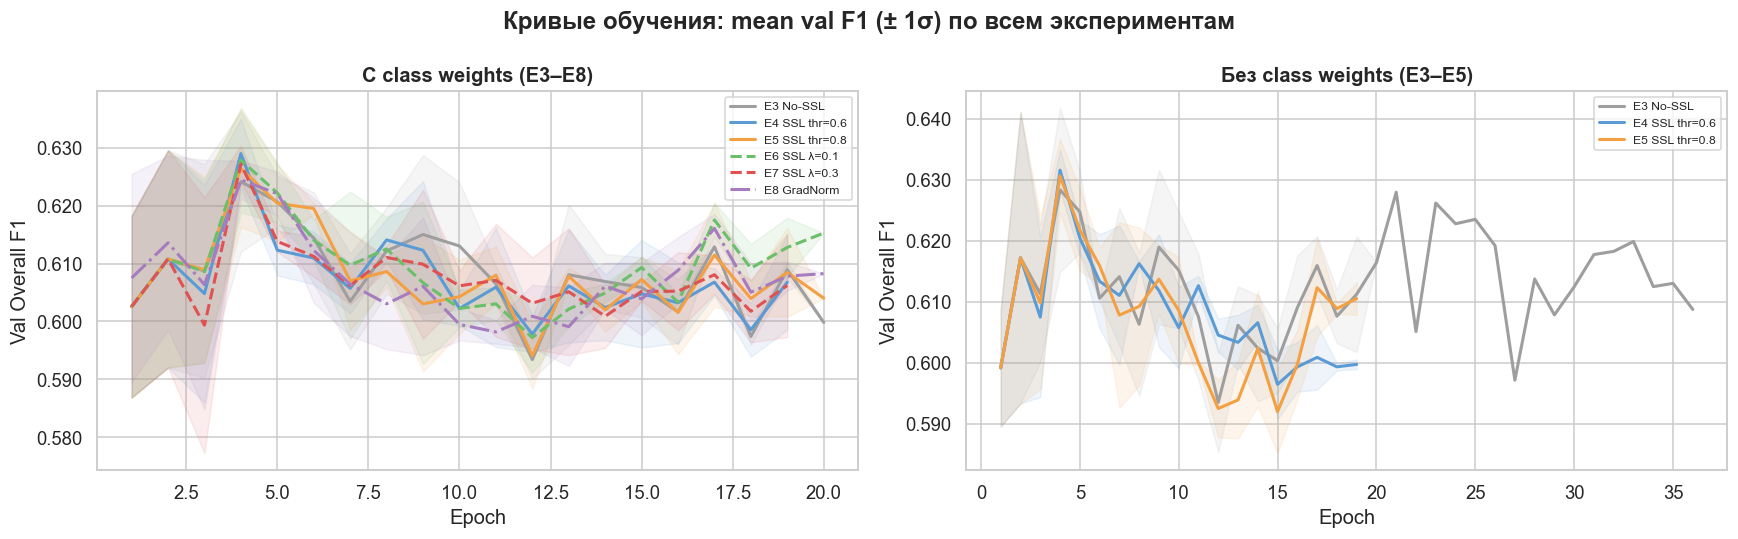

In [9]:
# Все эксперименты на одном графике (only best_models, mean кривая)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (hists, title) in zip(axes, [
    (hists_w,  "С class weights (E3–E8)"),
    (hists_wo, "Без class weights (E3–E5)"),
]):
    groups = {}
    for key, h in hists.items():
        base = get_exp_base(key)
        if base:
            groups.setdefault(base, []).append(h["val_overall_f1"])

    for base, curves in sorted(groups.items()):
        meta = EXP_META.get(base, {"color": "#555", "label": base, "ls": "-"})
        max_len = max(len(c) for c in curves)
        arr = np.full((len(curves), max_len), np.nan)
        for j, c in enumerate(curves):
            arr[j, :len(c)] = c
        mean = np.nanmean(arr, axis=0)
        std  = np.nanstd(arr,  axis=0)
        epochs = np.arange(1, max_len + 1)
        ax.plot(epochs, mean, color=meta["color"], ls=meta["ls"],
                linewidth=2, label=meta["label"])
        ax.fill_between(epochs, mean - std, mean + std, alpha=0.1, color=meta["color"])

    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Val Overall F1")
    ax.legend(fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))

plt.suptitle("Кривые обучения: mean val F1 (± 1σ) по всем экспериментам", fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Кривые потерь: supervised vs SSL (best_models)

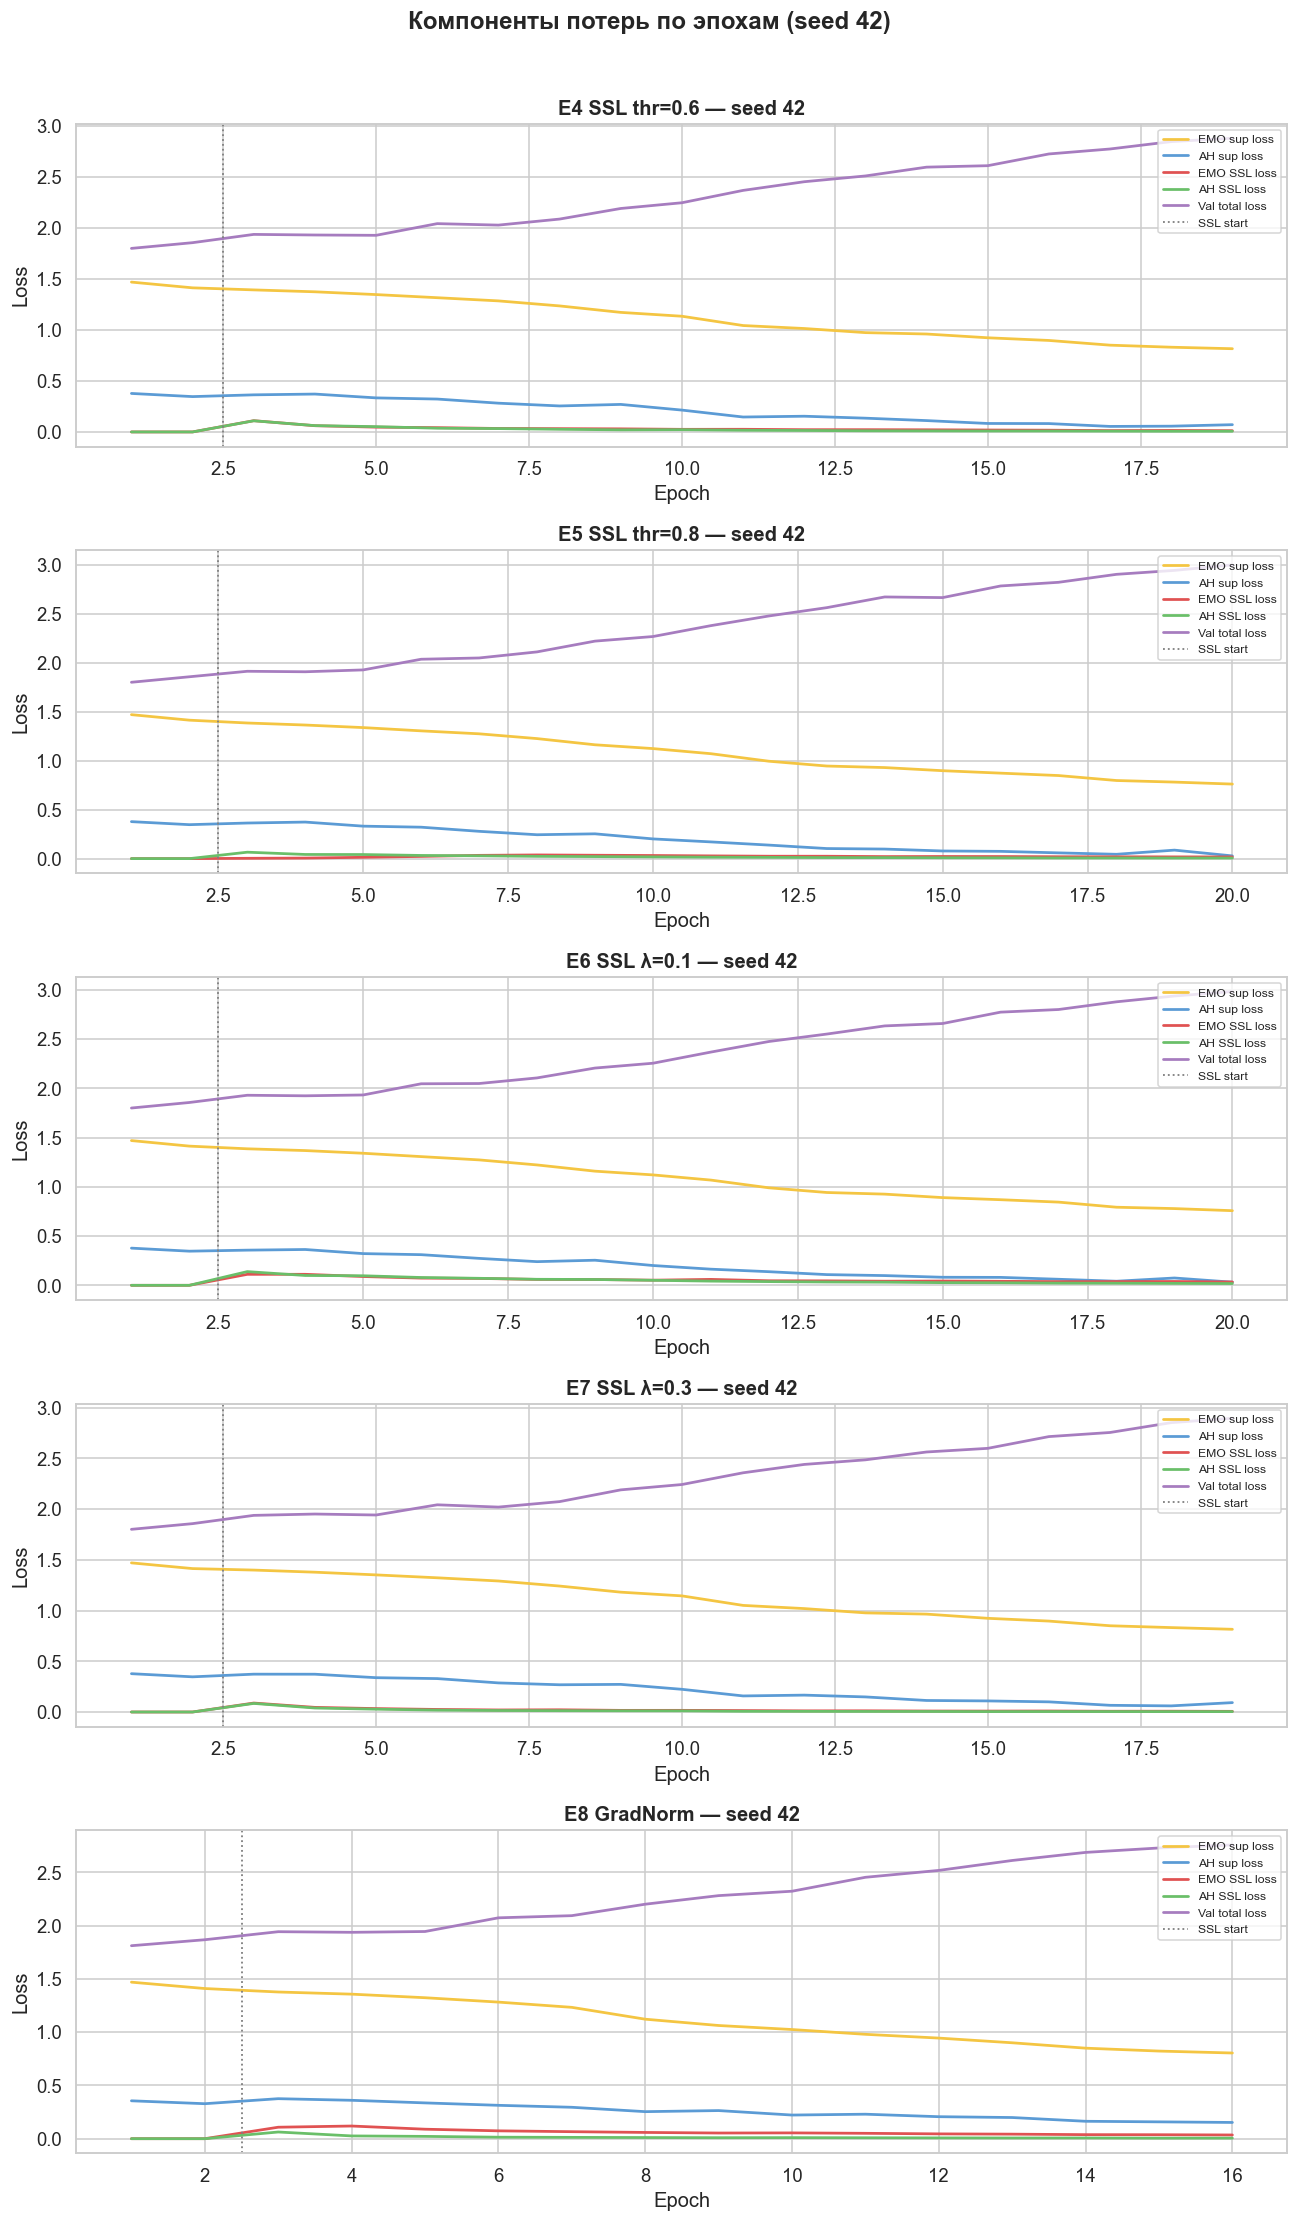

In [10]:
# Потери по компонентам для seed42 каждого эксперимента
loss_keys = {
    "train_loss_emo_sup": ("EMO sup loss",  "#f4c542"),
    "train_loss_ah_sup":  ("AH sup loss",   "#5b9bd5"),
    "train_loss_emo_ssl": ("EMO SSL loss",  "#e05252"),
    "train_loss_ah_ssl":  ("AH SSL loss",   "#6abf69"),
    "val_loss":           ("Val total loss","#a67cbf"),
}

ssl_exps = [e for e in EXP_META if e != "E3_fusion_no_ssl"]
n = len(ssl_exps)
fig, axes = plt.subplots(n, 1, figsize=(12, 4 * n), sharex=False)
if n == 1:
    axes = [axes]

for ax, exp in zip(axes, ssl_exps):
    key42 = f"{exp}_seed42"
    if key42 not in hists_w:
        ax.set_visible(False)
        continue
    h = hists_w[key42]
    epochs = np.arange(1, len(h["train_loss"]) + 1)
    for lk, (label, color) in loss_keys.items():
        if lk in h:
            ax.plot(epochs, h[lk], label=label, color=color, linewidth=1.8)
    # warmup border
    if "ssl_warmup_epochs" in h:
        warmup = h.get("ssl_warmup_epochs", 2)
    else:
        warmup = 2
    ax.axvline(warmup + 0.5, color="gray", ls=":", linewidth=1.2, label="SSL start")
    ax.set_title(f"{EXP_META[exp]['label']} — seed 42", fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend(fontsize=8, loc="upper right")

plt.suptitle("Компоненты потерь по эпохам (seed 42)", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 6. SSL-динамика: покрытие псевдо-меток по эпохам

`cov_ssl_emo` = доля unlabeled-EMO сэмплов, прошедших confidence-порог.  
`cov_ssl_ah`  = то же для AH.

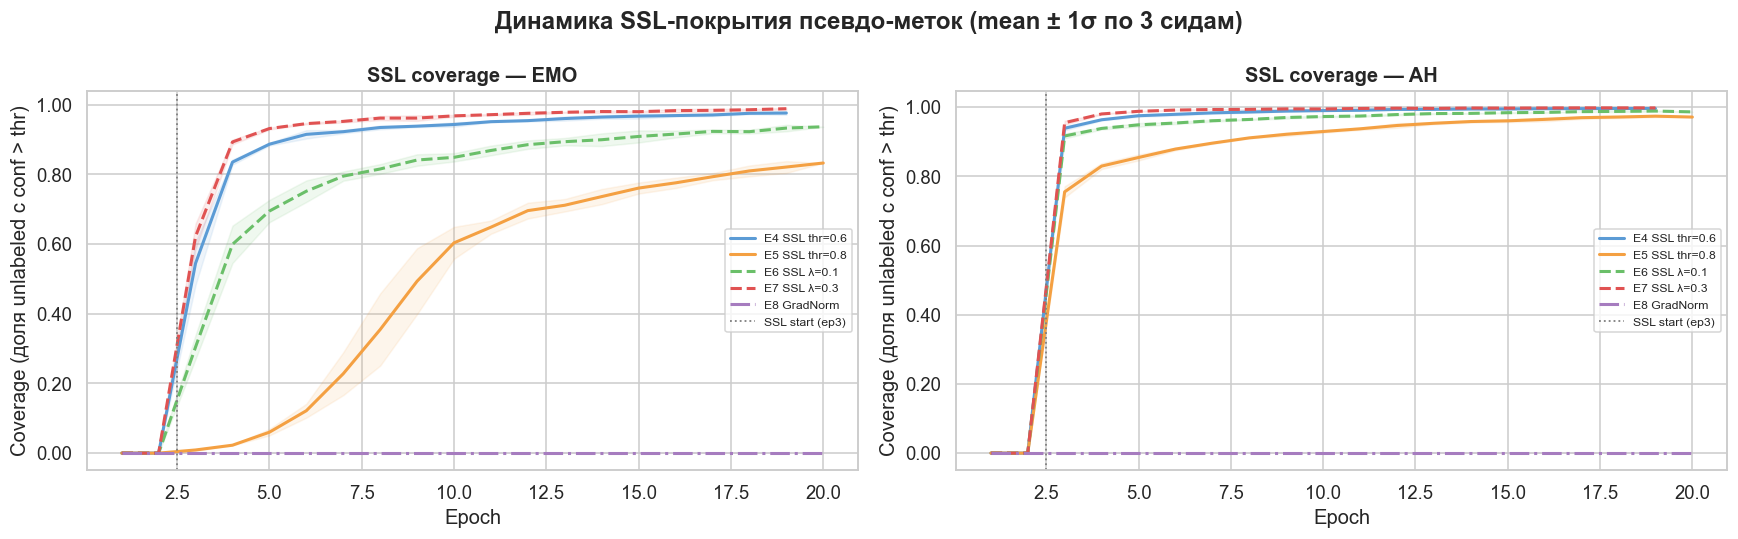

In [11]:
ssl_exps_with_cov = [e for e in EXP_META if e != "E3_fusion_no_ssl"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (task, cov_key, n_key, color) in zip(axes, [
    ("EMO", "train_cov_ssl_emo", "train_n_ssl_emo", "#e05252"),
    ("AH",  "train_cov_ssl_ah",  "train_n_ssl_ah",  "#5b9bd5"),
]):
    for exp in ssl_exps_with_cov:
        curves = []
        for seed in SEEDS:
            k = f"{exp}_seed{seed}"
            if k in hists_w and cov_key in hists_w[k]:
                curves.append(hists_w[k][cov_key])
        if not curves:
            continue
        meta = EXP_META[exp]
        max_len = max(len(c) for c in curves)
        arr = np.full((len(curves), max_len), np.nan)
        for j, c in enumerate(curves):
            arr[j, :len(c)] = c
        mean = np.nanmean(arr, axis=0)
        std  = np.nanstd(arr,  axis=0)
        epochs = np.arange(1, max_len + 1)
        ax.plot(epochs, mean, color=meta["color"], ls=meta["ls"],
                linewidth=2, label=meta["label"])
        ax.fill_between(epochs, mean - std, mean + std, alpha=0.1, color=meta["color"])

    ax.axvline(2.5, color="gray", ls=":", linewidth=1.2, label="SSL start (ep3)")
    ax.set_title(f"SSL coverage — {task}", fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Coverage (доля unlabeled с conf > thr)")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    ax.legend(fontsize=8)

plt.suptitle("Динамика SSL-покрытия псевдо-меток (mean ± 1σ по 3 сидам)", fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Распределение EMO псевдо-меток по классам (bias анализ)

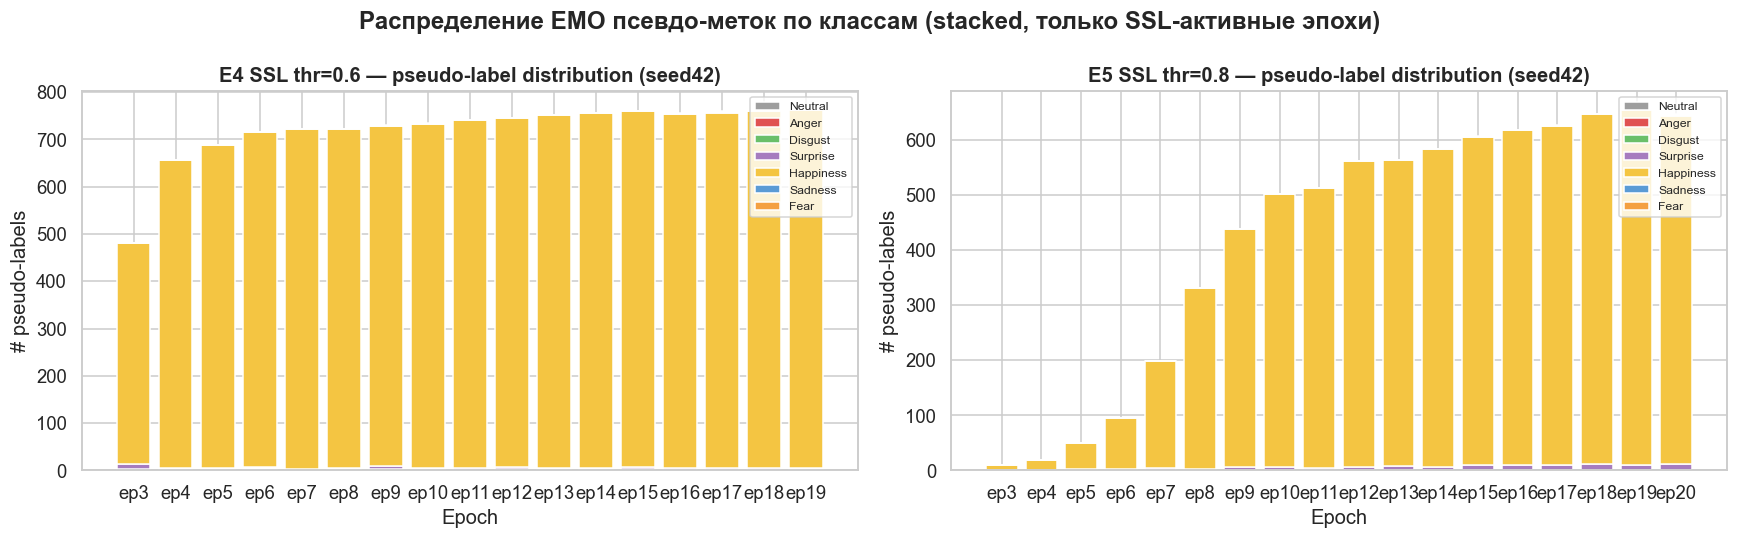

In [12]:
# pseudo_emo_hist: список списков [n_Neutral, n_Anger, n_Disgust, n_Surprise, n_Happiness, n_Sadness, n_Fear]
# Берём E4 (thr=0.6) и E5 (thr=0.8), seed=42, смотрим эволюцию по эпохам

EMO_ORDER = ["Neutral", "Anger", "Disgust", "Surprise", "Happiness", "Sadness", "Fear"]
EMO_COLORS = ["#9e9e9e", "#e05252", "#6abf69", "#a67cbf", "#f4c542", "#5b9bd5", "#f4a042"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, exp in zip(axes, ["E4_fusion_ssl", "E5_fusion_ssl_thr08"]):
    key = f"{exp}_seed42"
    if key not in hists_w or "train_pseudo_emo_hist" not in hists_w[key]:
        ax.text(0.5, 0.5, "Нет данных", ha="center", va="center", transform=ax.transAxes)
        continue
    hist = np.array(hists_w[key]["train_pseudo_emo_hist"])  # [epochs, 7]
    # Показываем только эпохи где SSL активен (сумма > 0)
    active = hist.sum(axis=1) > 0
    hist_active = hist[active]
    epoch_labels = [f"ep{i+1}" for i, a in enumerate(active) if a]

    # Stacked bar
    bottom = np.zeros(len(hist_active))
    for j, (emo, color) in enumerate(zip(EMO_ORDER, EMO_COLORS)):
        vals = hist_active[:, j].astype(float)
        ax.bar(epoch_labels, vals, bottom=bottom, label=emo, color=color, edgecolor="white")
        bottom += vals

    ax.set_title(f"{EXP_META[exp]['label']} — pseudo-label distribution (seed42)", fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("# pseudo-labels")
    ax.legend(fontsize=8, loc="upper right")

plt.suptitle("Распределение EMO псевдо-меток по классам (stacked, только SSL-активные эпохи)", fontweight="bold")
plt.tight_layout()
plt.show()

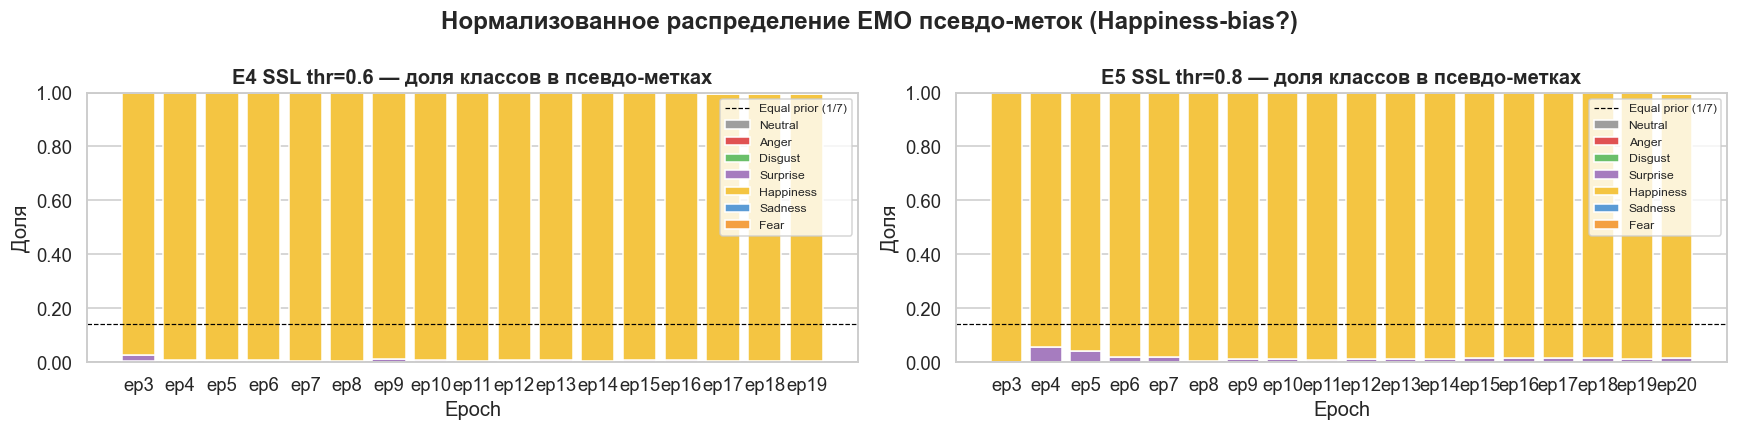

In [13]:
# Нормализованное распределение (доля каждого класса) — наглядно видно bias
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

for ax, exp in zip(axes, ["E4_fusion_ssl", "E5_fusion_ssl_thr08"]):
    key = f"{exp}_seed42"
    if key not in hists_w or "train_pseudo_emo_hist" not in hists_w[key]:
        continue
    hist = np.array(hists_w[key]["train_pseudo_emo_hist"], dtype=float)
    active = hist.sum(axis=1) > 0
    hist_active = hist[active]
    epoch_labels = [f"ep{i+1}" for i, a in enumerate(active) if a]

    # Нормализация по строкам
    row_sums = hist_active.sum(axis=1, keepdims=True)
    hist_norm = hist_active / np.where(row_sums == 0, 1, row_sums)

    bottom = np.zeros(len(hist_norm))
    for j, (emo, color) in enumerate(zip(EMO_ORDER, EMO_COLORS)):
        vals = hist_norm[:, j]
        ax.bar(epoch_labels, vals, bottom=bottom, label=emo, color=color, edgecolor="white")
        bottom += vals

    ax.set_title(f"{EXP_META[exp]['label']} — доля классов в псевдо-метках", fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Доля")
    ax.axhline(1/7, color="black", ls="--", linewidth=0.8, label="Equal prior (1/7)")
    ax.legend(fontsize=8, loc="upper right")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

plt.suptitle("Нормализованное распределение EMO псевдо-меток (Happiness-bias?)", fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Стабильность между сидами

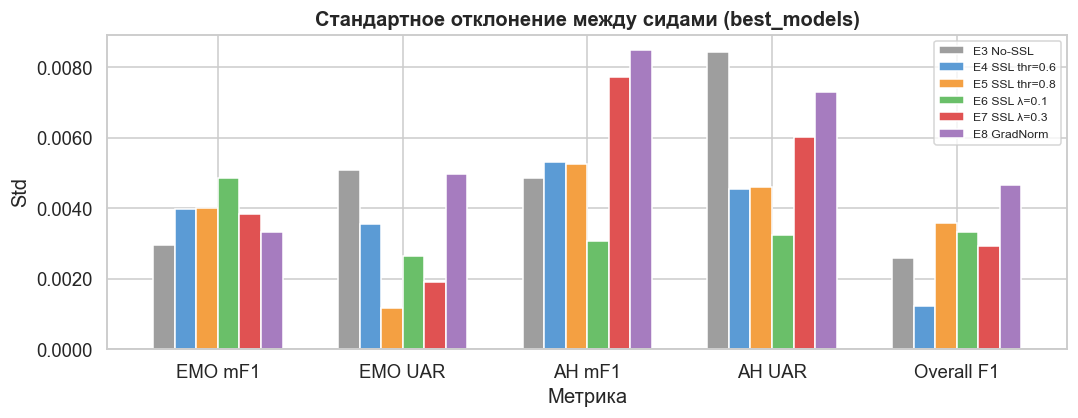


Seed-wise test scores (best_models):

  E3 No-SSL:
    seed 42: emo_mf1=0.5841      seed 0: emo_mf1=0.5788      seed 123: emo_mf1=0.5772  
    seed 42: ah_mf1=0.6599      seed 0: ah_mf1=0.6695      seed 123: ah_mf1=0.6587  
    seed 42: overall_f1=0.6220      seed 0: overall_f1=0.6242      seed 123: overall_f1=0.6179  

  E4 SSL thr=0.6:
    seed 42: emo_mf1=0.5756      seed 0: emo_mf1=0.5659      seed 123: emo_mf1=0.5702  
    seed 42: ah_mf1=0.6483      seed 0: ah_mf1=0.6596      seed 123: ah_mf1=0.6595  
    seed 42: overall_f1=0.6120      seed 0: overall_f1=0.6128      seed 123: overall_f1=0.6149  

  E5 SSL thr=0.8:
    seed 42: emo_mf1=0.5771      seed 0: emo_mf1=0.5694      seed 123: emo_mf1=0.5785  
    seed 42: ah_mf1=0.6673      seed 0: ah_mf1=0.6576      seed 123: ah_mf1=0.6551  
    seed 42: overall_f1=0.6222      seed 0: overall_f1=0.6135      seed 123: overall_f1=0.6168  

  E6 SSL λ=0.1:
    seed 42: emo_mf1=0.5777      seed 0: emo_mf1=0.5677      seed 123: emo_mf1=0.57

In [15]:
# Std между сидами по каждой метрике
std_rows = []
for exp, metrics in ab_w.items():
    row = {"experiment": EXP_META.get(exp, {}).get("label", exp)}
    for m in METRICS:
        vals = np.array([v for v in metrics[m] if v is not None])
        row[METRIC_LABELS[m]] = vals.std()
    std_rows.append(row)

std_df = pd.DataFrame(std_rows).set_index("experiment")

fig, ax = plt.subplots(figsize=(10, 4))
std_df.T.plot(kind="bar", ax=ax, width=0.7, edgecolor="white",
              color=[EXP_META.get(e, {}).get("color", "#aaa") for e in ab_w.keys()])
ax.set_title("Стандартное отклонение между сидами (best_models)", fontweight="bold")
ax.set_xlabel("Метрика")
ax.set_ylabel("Std")
ax.legend(fontsize=8, loc="upper right")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.4f"))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nSeed-wise test scores (best_models):")
for exp, metrics in ab_w.items():
    print(f"\n  {EXP_META.get(exp,{}).get('label', exp)}:")
    for m in ["emo_mf1", "ah_mf1", "overall_f1"]:
        vals = [v for v in metrics[m] if v is not None]
        for seed, v in zip(SEEDS, vals):
            print(f"    seed {seed}: {m}={v:.4f}", end="  ")
        print()

In [16]:
# Ранжирование лучшего эксперимента по каждой метрике
print("Лучший эксперимент по каждой метрике (best_models):\n")
for m in METRICS:
    best_exp = max(ab_w.keys(), key=lambda e: np.mean([v for v in ab_w[e][m] if v is not None]))
    best_val = np.mean([v for v in ab_w[best_exp][m] if v is not None])
    print(f"  {METRIC_LABELS[m]:<12}: {EXP_META.get(best_exp,{}).get('label',best_exp):<20}  {best_val:.4f}")

print()
print("Ранжирование по overall_f1 (best_models):\n")
ranking = sorted(ab_w.keys(),
                 key=lambda e: np.mean([v for v in ab_w[e]["overall_f1"] if v is not None]),
                 reverse=True)
for rank, exp in enumerate(ranking, 1):
    m_val = np.mean([v for v in ab_w[exp]["overall_f1"] if v is not None])
    s_val = np.std([v for v in ab_w[exp]["overall_f1"] if v is not None])
    print(f"  #{rank}  {EXP_META.get(exp,{}).get('label',exp):<22}  {m_val:.4f} ±{s_val:.4f}")

Лучший эксперимент по каждой метрике (best_models):

  EMO mF1     : E3 No-SSL             0.5801
  EMO UAR     : E3 No-SSL             0.6128
  AH mF1      : E3 No-SSL             0.6627
  AH UAR      : E3 No-SSL             0.6797
  Overall F1  : E3 No-SSL             0.6214

Ранжирование по overall_f1 (best_models):

  #1  E3 No-SSL               0.6214 ±0.0026
  #2  E5 SSL thr=0.8          0.6175 ±0.0036
  #3  E8 GradNorm             0.6174 ±0.0046
  #4  E6 SSL λ=0.1            0.6161 ±0.0033
  #5  E7 SSL λ=0.3            0.6155 ±0.0029
  #6  E4 SSL thr=0.6          0.6132 ±0.0012


## 9. Выводы

In [18]:
print("=" * 70)
print("ИТОГОВЫЕ ВЫВОДЫ")
print("=" * 70)

e3_w  = np.mean([v for v in ab_w["E3_fusion_no_ssl"]["overall_f1"] if v is not None])
e4_w  = np.mean([v for v in ab_w["E4_fusion_ssl"]["overall_f1"] if v is not None])
e5_w  = np.mean([v for v in ab_w["E5_fusion_ssl_thr08"]["overall_f1"] if v is not None])
e8_w  = np.mean([v for v in ab_w["E8_fusion_gradnorm"]["overall_f1"] if v is not None])

e3_wo = np.mean([v for v in ab_wo["E3_fusion_no_ssl"]["overall_f1"] if v is not None])
e4_wo = np.mean([v for v in ab_wo["E4_fusion_ssl"]["overall_f1"] if v is not None])

e3_uar_gain = (np.mean([v for v in ab_w["E3_fusion_no_ssl"]["emo_uar"] if v is not None]) -
              np.mean([v for v in ab_wo["E3_fusion_no_ssl"]["emo_uar"] if v is not None]))
best_idx = ranking[0]
best_label = EXP_META.get(best_idx, {}).get('label', best_idx)
best_overall = np.mean([v for v in ab_w[best_idx]["overall_f1"] if v is not None])

print(f"""
1. SSL не улучшает overall F1 относительно базовой модели без SSL:
   E3 (No-SSL, с weights):  {e3_w:.4f}
   E4 (SSL thr=0.6):        {e4_w:.4f}  Δ = {e4_w-e3_w:+.4f}
   E5 (SSL thr=0.8):        {e5_w:.4f}  Δ = {e5_w-e3_w:+.4f}
   → SSL слегка ухудшает EMO mF1, практически не влияет на AH mF1.

2. GradNorm (E8) не превосходит E3 по overall F1:
   E8 (GradNorm):           {e8_w:.4f}  Δ vs E3 = {e8_w-e3_w:+.4f}

3. Влияние class weights для EMO:
   E3 с weights:            {e3_w:.4f}
   E3 без weights:          {e3_wo:.4f}  Δ = {e3_w-e3_wo:+.4f}
   E4 с weights:            {e4_w:.4f}
   E4 без weights:          {e4_wo:.4f}  Δ = {e4_w-e4_wo:+.4f}
   → Взвешивание: EMO UAR значимо улучшается (+{e3_uar_gain:.4f}), AH mF1 чуть хуже (модели используют один оптимизатор).

4. SSL pseudo-label bias (раздел 7):
   Псевдо-метки EMO почти целиком состоят из Happiness (>90%).
   При thr=0.6 покрытие EMO ~62% после warmup, AH ~94%.
   → SSL для EMO-задачи в текущей конфигурации усиливает дисбаланс,
     а не борется с ним. Нужна балансировка псевдо-меток по классам.

5. Лучшая конфигурация по overall_f1 (best_models):
   #{best_idx} {best_label}: {best_overall:.4f}

6. Стабильность (std по сидам) — все эксперименты стабильны (std < 0.005).
""")

ИТОГОВЫЕ ВЫВОДЫ

1. SSL не улучшает overall F1 относительно базовой модели без SSL:
   E3 (No-SSL, с weights):  0.6214
   E4 (SSL thr=0.6):        0.6132  Δ = -0.0082
   E5 (SSL thr=0.8):        0.6175  Δ = -0.0039
   → SSL слегка ухудшает EMO mF1, практически не влияет на AH mF1.

2. GradNorm (E8) не превосходит E3 по overall F1:
   E8 (GradNorm):           0.6174  Δ vs E3 = -0.0040

3. Влияние class weights для EMO:
   E3 с weights:            0.6214
   E3 без weights:          0.6158  Δ = +0.0056
   E4 с weights:            0.6132
   E4 без weights:          0.6217  Δ = -0.0085
   → Взвешивание: EMO UAR значимо улучшается (+0.0190), AH mF1 чуть хуже (модели используют один оптимизатор).

4. SSL pseudo-label bias (раздел 7):
   Псевдо-метки EMO почти целиком состоят из Happiness (>90%).
   При thr=0.6 покрытие EMO ~62% после warmup, AH ~94%.
   → SSL для EMO-задачи в текущей конфигурации усиливает дисбаланс,
     а не борется с ним. Нужна балансировка псевдо-меток по классам.

5. Луч

**ИТОГОВЫЕ ВЫВОДЫ**

1. SSL не улучшает overall F1 относительно базовой модели без SSL:  
   E3 (No-SSL, с weights):  0.6214    
   E4 (SSL thr=0.6):        0.6132  Δ = -0.0082  
   E5 (SSL thr=0.8):        0.6175  Δ = -0.0039     
   → SSL слегка ухудшает EMO mF1, практически не влияет на AH mF1       

2. GradNorm (E8) не превосходит E3 по overall F1:       
   E8 (GradNorm):           0.6174  Δ vs E3 = -0.0040       

3. Влияние class weights для EMO:       
   E3 с weights:            0.6214      
   E3 без weights:          0.6158  Δ = +0.0056     
   E4 с weights:            0.6132      
   E4 без weights:          0.6217  Δ = -0.0085     
   → Взвешивание: EMO UAR значимо улучшается (+0.0190), AH mF1 чуть хуже (модели используют один оптимизатор).      

4. SSL pseudo-label bias (раздел 7):        
   Псевдо-метки EMO почти целиком состоят из Happiness (>90%).      
   При thr=0.6 покрытие EMO ~62% после warmup, AH ~94%.     
   → SSL для EMO-задачи в текущей конфигурации усиливает дисбаланс, 
     а не борется с ним. Нужна балансировка псевдо-меток по классам.        

5. Лучшая конфигурация по overall_f1 (best_models):     
   #E3_fusion_no_ssl E3 No-SSL: 0.6214      

6. Стабильность (std по сидам) — все эксперименты стабильны (std < 0.005).      